In [1]:
# !pip install pandas numpy matplotlib seaborn holidays

### Data cleansing

In [2]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt

In [3]:
def wrangle(path, col_1, col_2):
    # Import data
    df = pd.read_csv(path)

    # Convert to datetime
    df[col_1] = pd.to_datetime(df[col_1])

    # Rename the column to 'Date'
    df.rename(columns={col_1: 'Date'}, inplace=True)

    # Replace missing values
    df[col_2] = df[col_2].replace('.', pd.NA)

    # Convert to numeric, coercing errors to NaN
    df[col_2] = pd.to_numeric(df[col_2], errors='coerce')

    # Only select data between 2000-01-01 and 2024-12-31
    df = df[(df['Date'] >= '2000-01-01') & (df['Date'] <= '2024-12-31')]

    # Set index
    df = df.set_index('Date')

    return df

In [4]:
vix = wrangle("/Users/alexzheng/Developer/GitHub/Forecasting-Yen-Carry-Trade-Risk-Using-an-LLM/data/vix_updated.csv",
              "Date",
              "VIXCLS")
vix

,VIXCLS
Date,
2000-01-03,24.21
2000-01-04,27.01
2000-01-05,26.41
2000-01-06,25.73
2000-01-07,21.72
...,...
2024-12-25,NaN
2024-12-26,14.73
2024-12-27,15.95


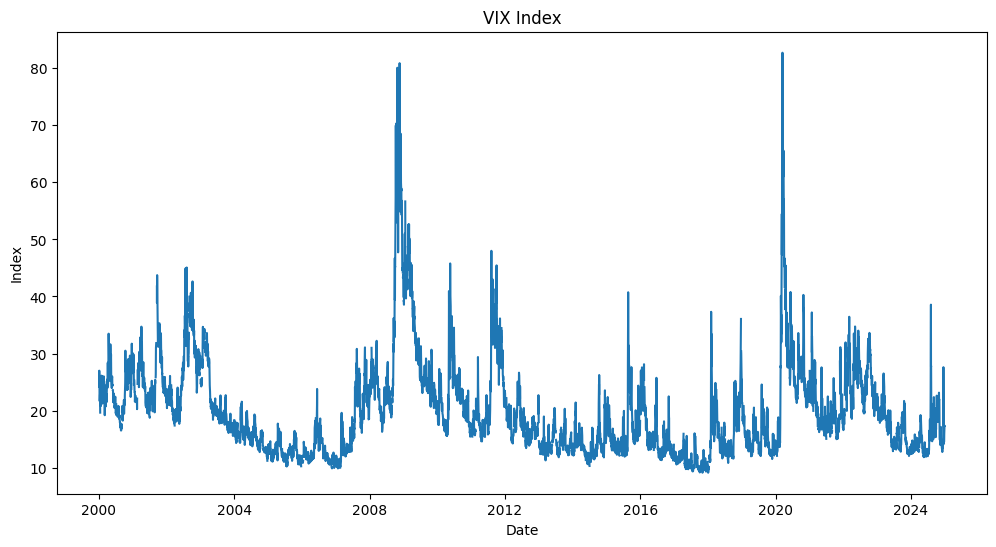

In [5]:
plt.figure(figsize=(12, 6))
plt.plot(vix.index, vix['VIXCLS'])
plt.xlabel('Date')
plt.ylabel('Index')
plt.title("VIX Index");

In [6]:
JPY_exchange_rate_per_USD = wrangle("/Users/alexzheng/Developer/GitHub/Forecasting-Yen-Carry-Trade-Risk-Using-an-LLM/data/ER_updated.csv",
                                    "Date",
                                    "DEXJPUS")
JPY_exchange_rate_per_USD

,DEXJPUS
Date,
2000-01-03,101.70
2000-01-04,103.09
2000-01-05,103.77
2000-01-06,105.19
2000-01-07,105.17
...,...
2024-12-25,NaN
2024-12-26,158.01
2024-12-27,157.73


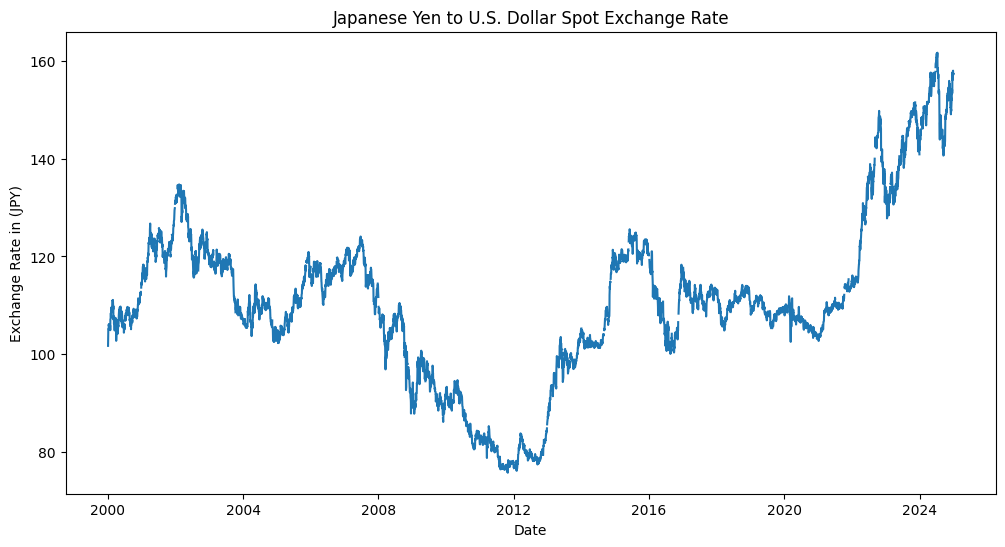

In [7]:
plt.figure(figsize=(12, 6))
plt.plot(JPY_exchange_rate_per_USD.index, JPY_exchange_rate_per_USD['DEXJPUS'])
plt.xlabel('Date')
plt.ylabel('Exchange Rate in (JPY)')
plt.title("Japanese Yen to U.S. Dollar Spot Exchange Rate");

In [8]:
Japan_IR = wrangle("/Users/alexzheng/Developer/GitHub/Forecasting-Yen-Carry-Trade-Risk-Using-an-LLM/data/JP_IR_updated.csv",
                   "Date",
                   "Japan Government Debt - 10 Year")

Japan_IR

,Japan Government Debt - 10 Year
Date,
2000-01-01,1.600
2000-01-02,1.600
2000-01-03,1.600
2000-01-04,1.660
2000-01-05,1.640
...,...
2024-12-24,1.088
2024-12-26,1.102
2024-12-27,1.115


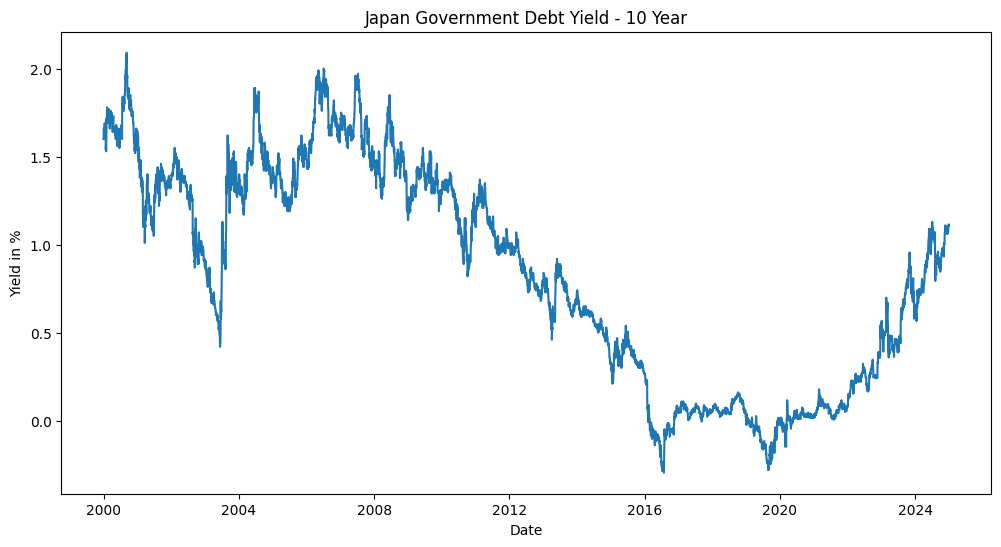

In [9]:
plt.figure(figsize=(12, 6))
plt.plot(Japan_IR.index, Japan_IR['Japan Government Debt - 10 Year'])
plt.xlabel('Date')
plt.ylabel('Yield in %')
plt.title("Japan Government Debt Yield - 10 Year");

In [10]:
US_IR = wrangle("/Users/alexzheng/Developer/GitHub/Forecasting-Yen-Carry-Trade-Risk-Using-an-LLM/data/US_IR_updated.csv",
                "Date",
                "DGS10")
US_IR

,DGS10
Date,
2000-01-03,6.58
2000-01-04,6.49
2000-01-05,6.62
2000-01-06,6.57
2000-01-07,6.52
...,...
2024-12-25,NaN
2024-12-26,4.58
2024-12-27,4.62


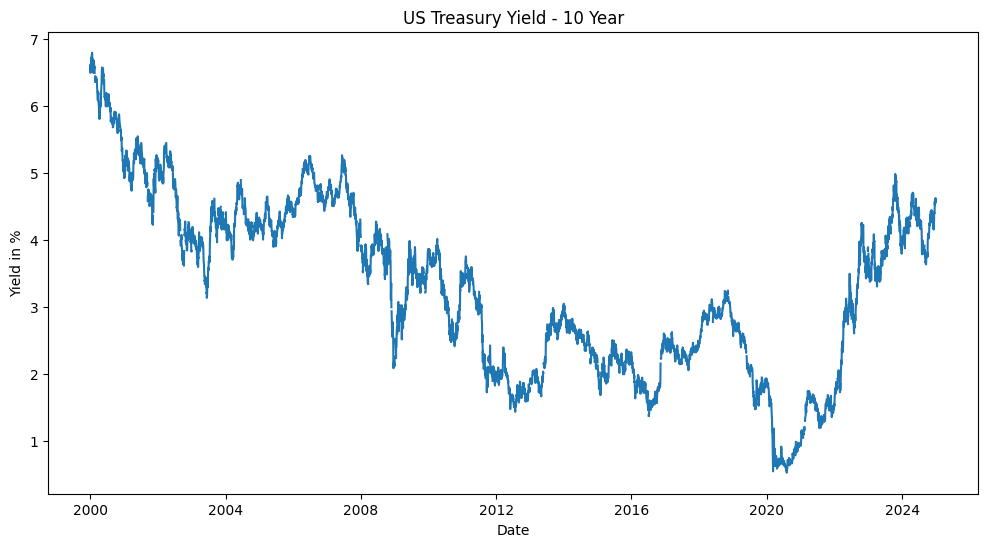

In [11]:
plt.figure(figsize=(12, 6))
plt.plot(US_IR.index, US_IR['DGS10'])
plt.xlabel('Date')
plt.ylabel('Yield in %')
plt.title("US Treasury Yield - 10 Year");

#### Combining the four data frames

In [12]:

# Renaming columns 
vix.rename(columns={"VIXCLS": "VIX_Index"}, inplace=True)
JPY_exchange_rate_per_USD.rename(columns={"DEXJPUS": "JPY_USD_Exchange_Rate"}, inplace=True)
Japan_IR.rename(columns={"Japan Government Debt - 10 Year": "Japan_10Y_IR"}, inplace=True)
US_IR.rename(columns={"DGS10": "US_10Y_IR"}, inplace=True)

# Performing outer joins to keep all data
combined_df = pd.merge(vix, JPY_exchange_rate_per_USD, on='Date', how='outer')
combined_df = pd.merge(combined_df, Japan_IR, on='Date', how='outer')
combined_df = pd.merge(combined_df, US_IR, on='Date', how='outer')

# Sorting by date for a cleaner view
combined_df.sort_index(inplace=True)

# Displaying the final dataframe and saving it
print(combined_df.head(10)) 
print(combined_df.tail(10)) 
combined_df.to_csv("/Users/alexzheng/Developer/GitHub/Forecasting-Yen-Carry-Trade-Risk-Using-an-LLM/data/combined_data_full.csv", index=True)

            VIX_Index  JPY_USD_Exchange_Rate  Japan_10Y_IR  US_10Y_IR
Date                                                                 
2000-01-01        NaN                    NaN          1.60        NaN
2000-01-02        NaN                    NaN          1.60        NaN
2000-01-03      24.21                 101.70          1.60       6.58
2000-01-04      27.01                 103.09          1.66       6.49
2000-01-05      26.41                 103.77          1.64       6.62
2000-01-06      25.73                 105.19          1.62       6.57
2000-01-07      21.72                 105.17          1.65       6.52
2000-01-08        NaN                    NaN          1.65        NaN
2000-01-09        NaN                    NaN          1.65        NaN
2000-01-10      21.71                 105.28          1.65       6.57
            VIX_Index  JPY_USD_Exchange_Rate  Japan_10Y_IR  US_10Y_IR
Date                                                                 
2024-12-18      27.6

In [13]:
print(f"The number of non-NaN values: \n{combined_df.count()}")
print("\n")
print(f"The number of NaN values: \n{combined_df.isna().sum()}")

The number of non-NaN values: 
VIX_Index                6309
JPY_USD_Exchange_Rate    6268
Japan_10Y_IR             7835
US_10Y_IR                6253
dtype: int64


The number of NaN values: 
VIX_Index                1560
JPY_USD_Exchange_Rate    1601
Japan_10Y_IR               34
US_10Y_IR                1616
dtype: int64


In [14]:
# # Interpolation to fill missing values
# combined_df = combined_df.interpolate(method='time').ffill()

# Drop rows with NaN values
combined_df.dropna(inplace=True)

# Count NaN values in each column
print(f"The number of non-NaN values: \n{combined_df.count()}")
print("\n")
print(f"The number of NaN values: \n{combined_df.isna().sum()}")

The number of non-NaN values: 
VIX_Index                6215
JPY_USD_Exchange_Rate    6215
Japan_10Y_IR             6215
US_10Y_IR                6215
dtype: int64


The number of NaN values: 
VIX_Index                0
JPY_USD_Exchange_Rate    0
Japan_10Y_IR             0
US_10Y_IR                0
dtype: int64


In [15]:
combined_df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 6215 entries, 2000-01-03 to 2024-12-31
Data columns (total 4 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   VIX_Index              6215 non-null   float64
 1   JPY_USD_Exchange_Rate  6215 non-null   float64
 2   Japan_10Y_IR           6215 non-null   float64
 3   US_10Y_IR              6215 non-null   float64
dtypes: float64(4)
memory usage: 242.8 KB


In [16]:
combined_df.describe()

,VIX_Index,JPY_USD_Exchange_Rate,Japan_10Y_IR,US_10Y_IR
count,6215.000000,6215.000000,6215.000000,6215.000000
mean,19.879136,110.864116,0.839902,3.285939
std,8.455819,16.770819,0.616196,1.306987
min,9.140000,75.720000,-0.295000,0.520000
25%,13.860000,103.190000,0.229000,2.200000
50%,17.870000,109.940000,0.883000,3.330000
75%,23.375000,118.935000,1.370000,4.280000
max,82.690000,161.730000,2.090000,6.790000


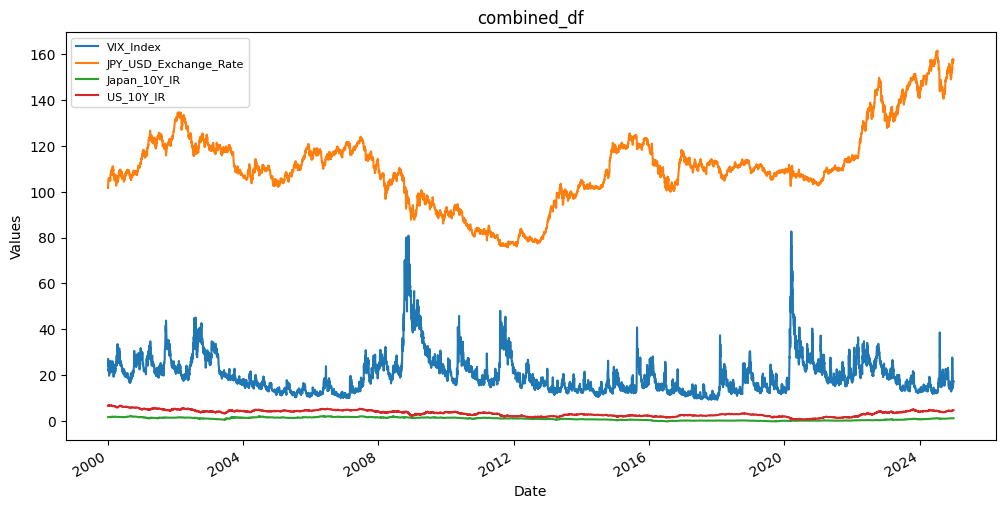

In [17]:
combined_df.plot(figsize=(12, 6), title="combined_df")
plt.xlabel('Date')
plt.ylabel('Values')
plt.legend(loc='upper left', prop={'size': 8});

In [18]:
# Convert Japan and US interest rates into decimals 
combined_df = combined_df.copy()

combined_df['US_10Y_IR'] = combined_df['US_10Y_IR'] / 100
combined_df['Japan_10Y_IR'] = combined_df['Japan_10Y_IR'] / 100

In [19]:
# Convert US and Japan 10Y bond yields to daily rates
combined_df['US_10Y_IR_daily'] = combined_df['US_10Y_IR'] / 252
combined_df['Japan_10Y_IR_daily'] = combined_df['Japan_10Y_IR'] / 252

In [20]:
# Save the full dataset 
combined_df.to_csv("/Users/alexzheng/Developer/GitHub/Forecasting-Yen-Carry-Trade-Risk-Using-an-LLM/data/combined_data_full.csv", float_format='%.7f', index=True)

## Predict future spot rates

In [22]:
combined_df.head()

,VIX_Index,JPY_USD_Exchange_Rate,Japan_10Y_IR,US_10Y_IR,US_10Y_IR_daily,Japan_10Y_IR_daily
Date,,,,,,
2000-01-03,24.21,101.70,0.0160,0.0658,0.000261,0.000063
2000-01-04,27.01,103.09,0.0166,0.0649,0.000258,0.000066
2000-01-05,26.41,103.77,0.0164,0.0662,0.000263,0.000065
2000-01-06,25.73,105.19,0.0162,0.0657,0.000261,0.000064
2000-01-07,21.72,105.17,0.0165,0.0652,0.000259,0.000065


In [23]:
# Predicting future spot rates based on historical spot rates
spot_rates = combined_df['JPY_USD_Exchange_Rate']
spot_rates

Date
2000-01-03    101.70
2000-01-04    103.09
2000-01-05    103.77
2000-01-06    105.19
2000-01-07    105.17
               ...  
2024-12-24    157.29
2024-12-26    158.01
2024-12-27    157.73
2024-12-30    157.26
2024-12-31    157.37
Name: JPY_USD_Exchange_Rate, Length: 6215, dtype: float64